In [1]:
import pandas as pd 
import numpy as np 
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
import seaborn as sns
import matplotlib.pyplot as plt 
import time
from dotenv import load_dotenv
import os
import math

In [3]:
load_dotenv(dotenv_path="../.env")

USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DBNAME = os.getenv("DB_NAME")

# Construct the SQLAlchemy connection string
DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

# Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)

# Test the connection
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print(f"Failed to connect: {e}")

Connection successful!


In [41]:
sql_query = text("""
SELECT 
r.CREATED_AT
  , c.STRAIN 
  , r.RECOVERY_SCORE
FROM PUBLIC.FACT_RECOVERY r
LEFT JOIN 
  PUBLIC.FACT_CYCLE c
  on r.CYCLE_ID = c.CYCLE_ID
ORDER BY r.CREATED_AT
""")

df = pd.read_sql_query(sql_query, con=engine)
df.head()

,created_at,strain,recovery_score
0,2024-01-01 06:30:35.725,14.368253,39
1,2024-01-01 18:40:45.962,14.368253,10
2,2024-01-02 05:40:45.369,12.028449,63
3,2024-01-03 06:20:32.420,5.601850,52
4,2024-01-04 07:40:53.976,12.666767,59


## Categorises strain scores into 4 different categories

In [45]:
df_wrangled = df.copy()
df_wrangled['strain_category'] = pd.cut(
    df['strain'],
    bins=[0, 5.25, 10.5, 15.75, 21],
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)
print(df_wrangled)


                 created_at     strain  recovery_score strain_category
0   2024-01-01 06:30:35.725  14.368253              39     Medium-High
1   2024-01-01 18:40:45.962  14.368253              10     Medium-High
2   2024-01-02 05:40:45.369  12.028449              63     Medium-High
3   2024-01-03 06:20:32.420   5.601850              52      Medium-Low
4   2024-01-04 07:40:53.976  12.666767              59     Medium-High
..                      ...        ...             ...             ...
956 2026-08-09 06:52:05.275   4.865791              16             Low
957 2026-08-10 05:03:30.437   9.119667              85      Medium-Low
958 2026-08-11 04:45:01.444  13.536211              81     Medium-High
959 2026-08-12 05:16:32.479   4.258755              60             Low
960 2026-08-13 06:08:08.154   4.120650              74             Low

[961 rows x 4 columns]


In [46]:
df_wrangled['recovery_category'] = pd.cut(
    df_wrangled['recovery_score'],
    bins=[0,33,66,100],
    labels=['Red', 'Amber', 'Green']
)


In [48]:
df_wrangled = df_wrangled.sort_values(by=['created_at'])
df_wrangled['recovery_category_shift'] = df_wrangled['recovery_category'].shift(-1)
df_wrangled.head(10)

try:
    df_cat = df_wrangled.drop(['strain','recovery_score', 'recovery_category'], axis=1, inplace=False)
except: pass

df_cat.tail()



,created_at,strain_category,recovery_category_shift
956,2026-08-09 06:52:05.275,Low,Green
957,2026-08-10 05:03:30.437,Medium-Low,Green
958,2026-08-11 04:45:01.444,Medium-High,Amber
959,2026-08-12 05:16:32.479,Low,Green
960,2026-08-13 06:08:08.154,Low,NaN


In [49]:

total_nights = len(df_cat['created_at'])
strain_cat_dict = {"Low":None, "Medium-Low":None, "Medium-High":None, "High":None}
for cat in strain_cat_dict.keys():
    df_strain_cat = df_cat[df_cat['strain_category']==cat]
    strain_nights = len(df_strain_cat)
    green_nights = len(df_strain_cat[df_strain_cat['recovery_category_shift']=='Green'])
    green_night_probability = green_nights / strain_nights

    strain_cat_dict.update({cat: [strain_nights, green_nights, green_night_probability]})

print(strain_cat_dict)

{'Low': [207, 129, 0.6231884057971014], 'Medium-Low': [493, 218, 0.4421906693711968], 'Medium-High': [201, 50, 0.24875621890547264], 'High': [60, 1, 0.016666666666666666]}


# Prediction of next day recovery base on prior day strain
P(Green Recovery | previous day strain) =
P(previous day strain | green recovery) * P(Green Recovery) / P(strain)

In [62]:
green_nights_total = len(df_cat[df_cat['recovery_category_shift']=='Green']) 
base_rate = green_nights_total / total_nights
for cat in strain_cat_dict.keys():
    likelihood = strain_cat_dict[cat][1] / green_nights_total
    
    prior=base_rate # green nights
    marginal = strain_cat_dict[cat][0] / total_nights
    print(f"{cat} likelihood: {likelihood:.2f} | Prior: {prior:.2f} | Marginal: {marginal:.2f}")

    posterior = (likelihood * prior) / marginal
    print(f"P(Green Recovery | {cat} Strain) = {posterior:.2f}")

Low likelihood: 0.32 | Prior: 0.41 | Marginal: 0.22
P(Green Recovery | Low Strain) = 0.62
Medium-Low likelihood: 0.55 | Prior: 0.41 | Marginal: 0.51
P(Green Recovery | Medium-Low Strain) = 0.44
Medium-High likelihood: 0.13 | Prior: 0.41 | Marginal: 0.21
P(Green Recovery | Medium-High Strain) = 0.25
High likelihood: 0.00 | Prior: 0.41 | Marginal: 0.06
P(Green Recovery | High Strain) = 0.02


/var/folders/gj/fsj5t7dj3534fnxcxkb14fb80000gn/T/ipykernel_92143/2623940818.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


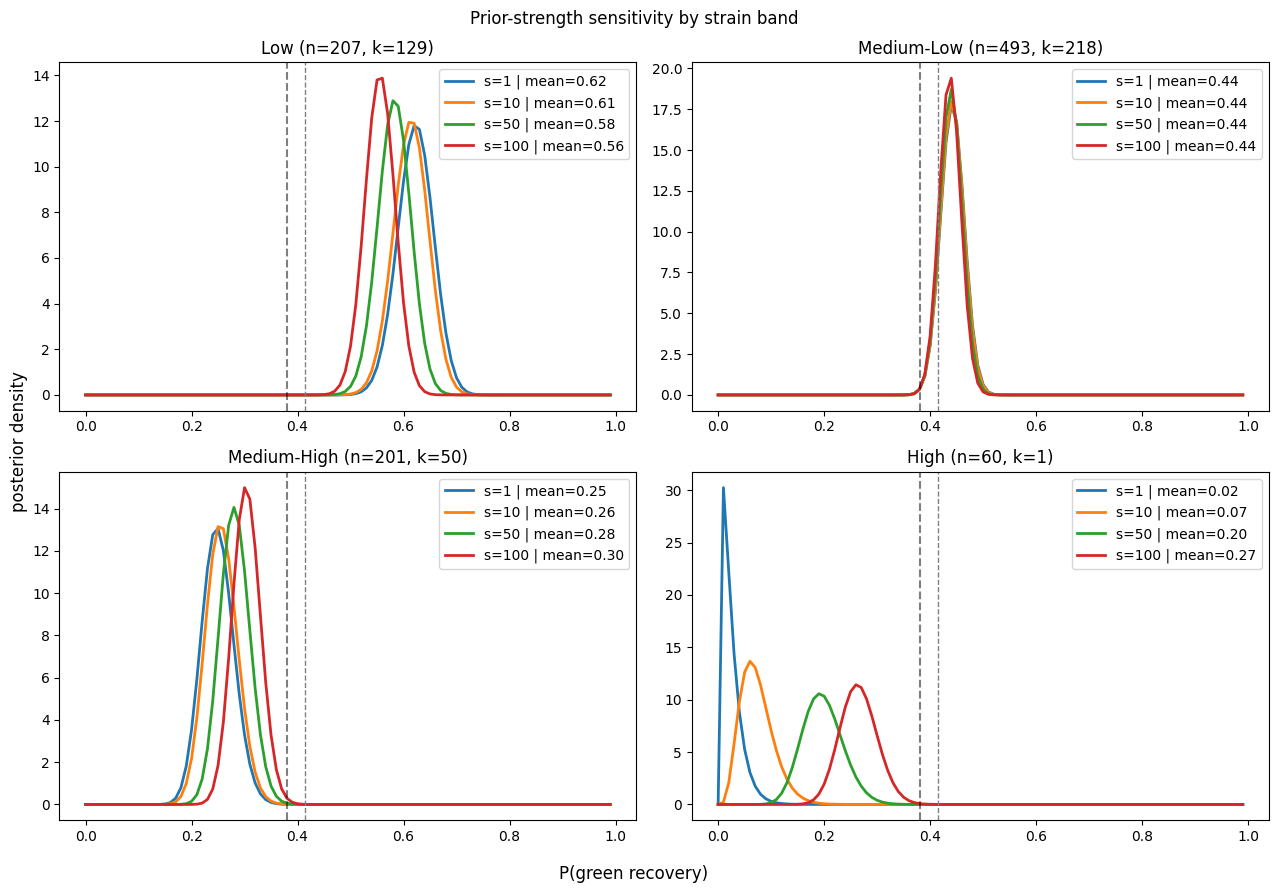

In [108]:
from scipy.stats import beta

x = np.arange(0,1,0.01) # creates an array of 0 to 1 with 0.01 intervals

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
base_rate = green_nights_total / total_nights
strength = [1, 10, 50, 100]
axes = axes.flatten() 
for i, cat in enumerate(strain_cat_dict.keys()):
    ax = axes[i]               # the panel for this band
    n, k = strain_cat_dict[cat][0], strain_cat_dict[cat][1]
    for s in strength:
        a0, b0 = base_rate * s, (1 - base_rate) * s
        a_post, b_post = a0 + k, b0 + (n-k)
        posterior_mean = a_post / (a_post + b_post)
        y = beta.pdf(x, a_post, b_post)
        ax.plot(x, y, linewidth=2, label=f"s={s} | mean={posterior_mean:.2f}")

    ax.axvline(base_rate, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"{cat} (n={n}, k={k})")
    ax.legend()
    ax.axvline(0.38, linestyle = 'dashed', color = 'black', alpha = 0.5)


fig.supxlabel("P(green recovery)")
fig.supylabel("posterior density")
fig.suptitle("Prior-strength sensitivity by strain band")
fig.tight_layout()
fig.show()


Based on the high band having a small count of nights vs the other bands, the mean becomes very sensitive to larger priors (as can be seen above), so to ensure that the raw data remains the driving factor, the strength of the priors was 10 nights of data at base rate.

The above visual makes it really clear to see how the posterior mean changes very slightly in the bigger bands.

Low: 0.61  [0.55, 0.68]  (n=207, raw=0.62)
Medium-Low: 0.44  [0.40, 0.49]  (n=493, raw=0.44)
Medium-High: 0.26  [0.20, 0.32]  (n=201, raw=0.25)
High: 0.07  [0.03, 0.14]  (n=60, raw=0.02)


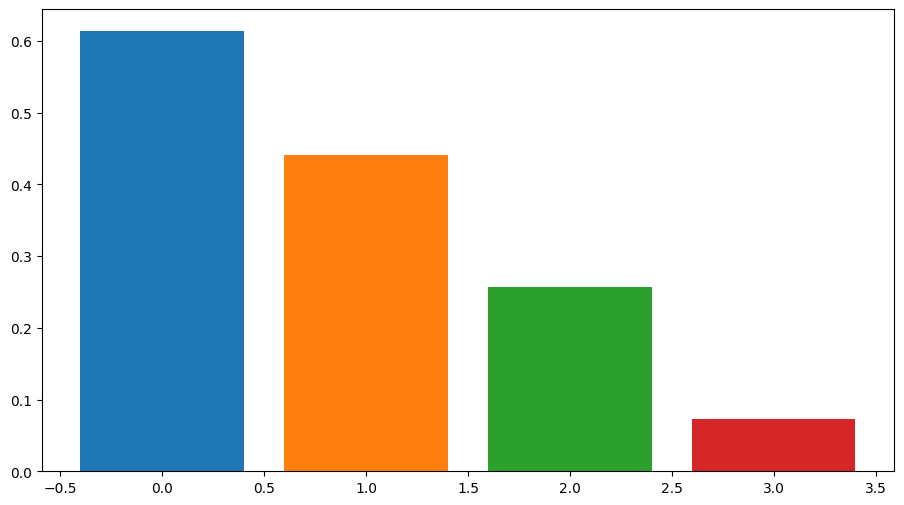

In [114]:

base_rate = green_nights_total / total_nights
s = 10
alpha_prior, beta_prior = base_rate * s, (1 - base_rate) * s

plt.figure(figsize = [11,6])

for i, cat in enumerate(strain_cat_dict.keys()):
    n, k = strain_cat_dict[cat][0], strain_cat_dict[cat][1]
    a_post, b_post = alpha_prior + k, beta_prior + (n - k)
    posterior_mean = a_post / (a_post + b_post)
    low, high = beta.ppf([0.025, 0.975], a_post, b_post)
    print(f"{cat}: {posterior_mean:.2f}  [{low:.2f}, {high:.2f}]  (n={n}, raw={k/n:.2f})")
    plt.bar(i, posterior_mean)

plt.show()

The 95% credbile intervals above show the values between which there is a 95% probability of the true P(Green Recovery | Strain) being between these values under a weakly informative base rate prior.